## CROMA per-pixel embeddings

Extract **spatially resolved** embeddings from CROMA (not GAP-pooled).

CROMA uses 8×8 patches on 120×120 input, producing a **15×15 grid of 768‑dim tokens**.  
Each token represents an **80 m × 80 m** area (8 px × 10 m/px).

This notebook:
1. Loads a 534×534 master tile and center-crops to 120×120 (CROMA input size)
2. Extracts the 15×15 patch token grid (before GAP)
3. Visualizes per-patch embeddings as spatial maps (PCA / similarity)
4. Supports optical, radar, and joint modes

In [1]:
import os
import glob
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from pathlib import Path
from sklearn.decomposition import PCA
from torchgeo.models import croma_base, CROMABase_Weights

# ── Configuration ──
SCRIPT_DIR = os.path.dirname(os.path.abspath("__file__"))

if os.path.exists(os.path.expanduser("~/thesis_tiles")):
    TILES_DIR = os.path.expanduser("~/thesis_tiles")
    SHP_DIR = os.path.join(SCRIPT_DIR, "data_shp")
else:
    TILES_DIR = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tiles"
    SHP_DIR = os.path.join(SCRIPT_DIR, "data_shp")

# CROMA input size and patch config
CROMA_INPUT = 120    # 120x120 pixels
PATCH_SIZE = 8       # 8x8 pixel patches
GRID_SIZE = CROMA_INPUT // PATCH_SIZE  # 15x15 tokens
EMBED_DIM = 768      # ViT-B embedding dimension
MASTER_TILE = 534    # downloaded tile size

# S2 L2A bands in download order -> CROMA expects 12 bands (no B10)
# Download: B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12 (already 12, matches CROMA)
CROMA_S2_BAND_INDICES = list(range(12))  # all 12 bands

# Device
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
print(f"Tiles dir: {TILES_DIR}")
print(f"CROMA: {CROMA_INPUT}x{CROMA_INPUT} input -> {GRID_SIZE}x{GRID_SIZE} patch grid -> {EMBED_DIM}-dim tokens")

/share/home/e2406749/.conda/envs/croma_viz/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Tiles dir: /share/home/e2406749/thesis_tiles
CROMA: 120x120 input -> 15x15 patch grid -> 768-dim tokens


## 1. Helper functions: loading, normalization, cropping

In [2]:
def normalize(x):
    """Per-channel robust normalization to [0, 1] (same as CROMA pretraining)."""
    x = x.float()
    imgs = []
    for ch in range(x.shape[1]):
        channel = x[:, ch, :, :]
        min_val = channel.mean() - 2 * channel.std()
        max_val = channel.mean() + 2 * channel.std()
        img = (channel - min_val) / (max_val - min_val + 1e-10)
        img = torch.clamp(img, 0, 1)
        imgs.append(img.unsqueeze(1))
    return torch.cat(imgs, dim=1)


def load_full_tile(tif_path, band_indices=None):
    """Load the full 534x534 tile (no crop)."""
    with rasterio.open(tif_path) as src:
        data = src.read().astype(np.float32)
        transform = src.transform
        crs = src.crs
    if band_indices is not None:
        data = data[band_indices]
    return data, transform, crs


def compute_window_positions(image_size, window_size):
    """Compute window start positions covering [0, image_size] without gaps.

    Returns positions where each window of size `window_size` starts.
    The last window is anchored to the right edge to cover the full image.
    """
    if image_size <= window_size:
        return [0]
    # Number of windows needed
    n = int(np.ceil((image_size - window_size) / (window_size * 0.8))) + 1
    if n < 2:
        n = 2
    # Evenly distribute, last position fixed at right edge
    positions = list(np.linspace(0, image_size - window_size, n).round().astype(int))
    return sorted(set(positions))


#There is an overlap of about 16% between windows in the 534x534 images - 25 windows
def sliding_windows(image, window_size=CROMA_INPUT):
    """Generate (y0, x0, crop) for sliding windows over a (C, H, W) image.

    Windows have size (window_size, window_size) and overlap as needed
    to cover the full image.
    """
    _, h, w = image.shape
    y_positions = compute_window_positions(h, window_size)
    x_positions = compute_window_positions(w, window_size)

    crops = []
    for y0 in y_positions:
        for x0 in x_positions:
            crop = image[:, y0:y0+window_size, x0:x0+window_size]
            crops.append((y0, x0, crop))
    return crops, y_positions, x_positions


def find_sample_tile(fid, product, window="evt"):
    pattern = os.path.join(TILES_DIR, product, f"fid_{fid}", window, "*", "tile_0.tif")
    tifs = sorted(glob.glob(pattern))
    return tifs[0] if tifs else None


def list_available_fids():
    s2_dir = os.path.join(TILES_DIR, "s2_l2a")
    s1_dir = os.path.join(TILES_DIR, "s1_grd")
    if not os.path.exists(s2_dir) or not os.path.exists(s1_dir):
        return []
    s2_fids = {d.replace("fid_", "") for d in os.listdir(s2_dir) if d.startswith("fid_")}
    s1_fids = {d.replace("fid_", "") for d in os.listdir(s1_dir) if d.startswith("fid_")}
    return sorted(s2_fids & s1_fids)

available_fids = list_available_fids()
print(f"FIDs with both S2 L2A and S1 GRD: {len(available_fids)}")
if available_fids:
    print(f"Examples: {available_fids[:10]}")

# Show window positions
positions = compute_window_positions(MASTER_TILE, CROMA_INPUT)
print(f"\nSliding window positions for 534x534 with 120x120 windows:")
print(f"  Positions: {positions}")
print(f"  Number of windows: {len(positions)}x{len(positions)} = {len(positions)**2}")
print(f"  Overlaps: {[positions[i+1]-positions[i] for i in range(len(positions)-1)]} (px between starts)")
print(f"  Window size: {CROMA_INPUT}px, so overlap = {CROMA_INPUT - (positions[1]-positions[0])}px")

FIDs with both S2 L2A and S1 GRD: 19
Examples: ['11', '122', '142', '143', '153', '161', '195', '216', '221', '228']

Sliding window positions for 534x534 with 120x120 windows:
  Positions: [np.int64(0), np.int64(83), np.int64(166), np.int64(248), np.int64(331), np.int64(414)]
  Number of windows: 6x6 = 36
  Overlaps: [np.int64(83), np.int64(83), np.int64(82), np.int64(83), np.int64(83)] (px between starts)
  Window size: 120px, so overlap = 37px


## 2. Load CROMA model and extract patch tokens

In [3]:
def load_croma_model(modalities):
    model = croma_base(weights=CROMABase_Weights.CROMA_VIT, modalities=modalities)
    model = model.to(device)
    if hasattr(model, 'attn_bias') and model.attn_bias is not None:
        model.attn_bias = model.attn_bias.to(device)
    model.eval()
    return model


def encode_crop(model, crop_data, modality):
      """Run a single 120x120 crop through CROMA, return (15, 15, 768) tokens."""
      x = torch.from_numpy(crop_data).unsqueeze(0)                                                                           
      x = normalize(x).to(device)             
                                                                                                                             
      captured = {}                                                                                                          
      encoder = model.s2_encoder if modality == "optical" else model.s1_encoder                                              
                                                                                                                             
      def hook(module, input, output):                                                                                       
          # output is the spatial tokens before pooling     
          captured['tokens'] = output                                                                                        
                                              
      h = encoder.register_forward_hook(hook)                                                                                
      with torch.no_grad():                                 
          if modality == "optical":                                                                                          
              _ = model(x_optical=x)
          else:                                                                                                              
              _ = model(x_sar=x)                            
      h.remove()                          

      out = captured['tokens']                                                                                               
      # Handle if output is a tuple (some ViTs return (tokens, attn))
      if isinstance(out, tuple):                                                                                             
          out = out[0]                                      
      tokens = out.cpu().numpy().squeeze()  # (225, 768) or (226, 768) if CLS
                                                                                                                             
      # Drop CLS token if present                                                                                            
      if tokens.shape[0] == GRID_SIZE * GRID_SIZE + 1:                                                                       
          tokens = tokens[1:]                                                                                                
                                                                                                                             
      return tokens.reshape(GRID_SIZE, GRID_SIZE, EMBED_DIM)


def extract_full_tile_tokens(model, full_tile, modality):
    """Sliding-window extraction over the full 534x534 tile.

    Returns a stitched token grid where overlap zones are averaged.
    Output shape: (token_h, token_w, 768) where token_h = 534/8 = 66 approx
    (we map back to the full tile resolution at patch scale).
    """
    crops, y_pos, x_pos = sliding_windows(full_tile, window_size=CROMA_INPUT)

    # Build a token map at patch resolution
    # Each pixel of the master tile maps to one token-patch position
    # Token position for pixel y is y // PATCH_SIZE
    full_h, full_w = full_tile.shape[1], full_tile.shape[2]
    token_h = full_h // PATCH_SIZE  # 534 // 8 = 66
    token_w = full_w // PATCH_SIZE

    # Accumulators for averaging overlaps
    token_sum = np.zeros((token_h, token_w, EMBED_DIM), dtype=np.float32)
    token_count = np.zeros((token_h, token_w), dtype=np.int32)

    for y0, x0, crop in crops:
        # Run inference on this crop
        crop_tokens = encode_crop(model, crop, modality)  # (15, 15, 768)

        # Where do these tokens land in the full token grid?
        ty0 = y0 // PATCH_SIZE
        tx0 = x0 // PATCH_SIZE
        ty1 = ty0 + GRID_SIZE
        tx1 = tx0 + GRID_SIZE

        # Clip to bounds (in case of off-by-one near edges)
        ty1 = min(ty1, token_h)
        tx1 = min(tx1, token_w)
        ch = ty1 - ty0
        cw = tx1 - tx0

        token_sum[ty0:ty1, tx0:tx1] += crop_tokens[:ch, :cw]
        token_count[ty0:ty1, tx0:tx1] += 1

    # Average where overlapping
    token_count = np.maximum(token_count, 1)  # avoid div by 0
    full_tokens = token_sum / token_count[..., np.newaxis]
    return full_tokens


print("Functions ready: encode_crop (single window), extract_full_tile_tokens (sliding window)")

Functions ready: encode_crop (single window), extract_full_tile_tokens (sliding window)


## 3. Pick a sample FID and extract embeddings

In [13]:
# Choose a FID (change this to explore different polygons)
FID = available_fids[4] if available_fids else None
print(f"Using FID: {FID}")

# Find tiles for all 3 windows
s2_tiles = {}
s1_tiles = {}
for window in ["evt", "bef", "aft"]:
    s2_path = find_sample_tile(FID, "s2_l2a", window)
    s1_path = find_sample_tile(FID, "s1_grd", window)
    if s2_path:
        s2_tiles[window] = s2_path
        print(f"  S2 {window}: {Path(s2_path).parent.name}")
    if s1_path:
        s1_tiles[window] = s1_path
        print(f"  S1 {window}: {Path(s1_path).parent.name}")

Using FID: 153
  S1 evt: S1A_IW_GRDH_1SDV_20230427T094911_20230427T094936_048280_05CE51_9F1D
  S2 bef: 20230214T142711_20230214T143425_T20LNR
  S1 bef: S1A_IW_GRDH_1SDV_20230109T094911_20230109T094936_046705_05993A_671C
  S2 aft: 20230515T142711_20230515T142713_T20LNR
  S1 aft: S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_048455_05D42C_BB80


In [14]:
model_opt = load_croma_model(['optical'])                                                                                  
# Print all attributes                                                                                                     
print([a for a in dir(model_opt) if not a.startswith('_')])
print("\nNamed children:")                                                                                                 
for name, module in model_opt.named_children():                                                                            
  print(f"  {name}: {type(module).__name__}")   

['T_destination', 'add_module', 'apply', 'attn_bias', 'bfloat16', 'buffers', 'call_super_init', 'children', 'compile', 'cpu', 'cuda', 'double', 'dump_patches', 'encoder_depth', 'encoder_dim', 'eval', 'extra_repr', 'float', 'forward', 'get_buffer', 'get_extra_state', 'get_parameter', 'get_submodule', 'half', 'image_size', 'ipu', 'load_state_dict', 'modalities', 'modules', 'mtia', 'named_buffers', 'named_children', 'named_modules', 'named_parameters', 'num_heads', 'num_patches', 'parameters', 'patch_size', 'register_backward_hook', 'register_buffer', 'register_forward_hook', 'register_forward_pre_hook', 'register_full_backward_hook', 'register_full_backward_pre_hook', 'register_load_state_dict_post_hook', 'register_load_state_dict_pre_hook', 'register_module', 'register_parameter', 'register_state_dict_post_hook', 'register_state_dict_pre_hook', 'requires_grad_', 's1_channels', 's2_GAP_FFN', 's2_channels', 's2_encoder', 'set_extra_state', 'set_submodule', 'share_memory', 'state_dict', 't

In [15]:
# Load and extract optical tokens for the FULL 534x534 tile (sliding window)
print("Loading optical model...")
model_opt = load_croma_model(['optical'])

optical_results = {}
for window, path in s2_tiles.items():
    data, transform, crs = load_full_tile(path, band_indices=CROMA_S2_BAND_INDICES)
    print(f"  {window}: full tile shape {data.shape}")
    tokens = extract_full_tile_tokens(model_opt, data, modality="optical")
    # GAP = mean over all spatial tokens
    gap = tokens.reshape(-1, EMBED_DIM).mean(axis=0)
    optical_results[window] = {
        'data': data, 'tokens': tokens, 'gap': gap,
        'transform': transform, 'crs': crs, 'path': path,
    }
    print(f"    -> tokens {tokens.shape}, gap norm={np.linalg.norm(gap):.2f}")

del model_opt
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Done.")

Loading optical model...
  bef: full tile shape (12, 534, 534)
    -> tokens (66, 66, 768), gap norm=16.59
  aft: full tile shape (12, 534, 534)
    -> tokens (66, 66, 768), gap norm=17.48
Done.


## 4. Visualize: PCA of patch tokens as spatial maps

Project the 768‑dim tokens to 3 principal components and display as RGB.  
Each pixel in the 15×15 map represents an 80 m × 80 m patch.

In [16]:
# Load polygon for overlay
import geopandas as gpd

shp_path = os.path.join(SHP_DIR, "label_polygons.shp")
if os.path.exists(shp_path):
    gdf = gpd.read_file(shp_path)
    gdf["fid"] = gdf["fid"].astype(int).astype(str)  # 1.0 -> "1"
    print(f"Loaded {len(gdf)} polygons")
else:
    gdf = None
    print(f"Shapefile not found at {shp_path}")


def get_polygon_pixels(fid, transform, crs):
    """Get polygon boundary in pixel coordinates."""
    if gdf is None:
        return None
    poly_row = gdf[gdf["fid"] == str(fid)]
    if poly_row.empty:
        return None
    poly_reproj = poly_row.to_crs(crs)
    coords_list = []
    for geom in poly_reproj.geometry:
        if geom.is_empty:
            continue
        geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
        for g in geoms:
            xs, ys = g.exterior.coords.xy
            pixel_coords = [(~transform * (x, y)) for x, y in zip(xs, ys)]
            coords_list.append(pixel_coords)
    return coords_list


def add_polygon_overlay(ax, fid, transform, crs, img_size=None):
    """Add polygon outline at native pixel scale."""
    coords_list = get_polygon_pixels(fid, transform, crs)
    if coords_list:
        for coords in coords_list:
            poly_patch = MplPolygon(coords, closed=True,
                                    edgecolor="red", facecolor="red", alpha=0.2, linewidth=2)
            ax.add_patch(poly_patch)


def add_polygon_overlay_on_grid(ax, fid, transform, crs, scale_factor):
    """Add polygon outline scaled to a downsampled grid (e.g. token grid)."""
    coords_list = get_polygon_pixels(fid, transform, crs)
    if coords_list:
        for coords in coords_list:
            scaled = [(x / scale_factor, y / scale_factor) for x, y in coords]
            poly_patch = MplPolygon(scaled, closed=True,
                                    edgecolor="red", facecolor="red", alpha=0.2, linewidth=2)
            ax.add_patch(poly_patch)

Loaded 389 polygons


PCA explained variance: [0.10089215 0.06735827 0.06515787]
Token grid shape: (66, 66, 768)


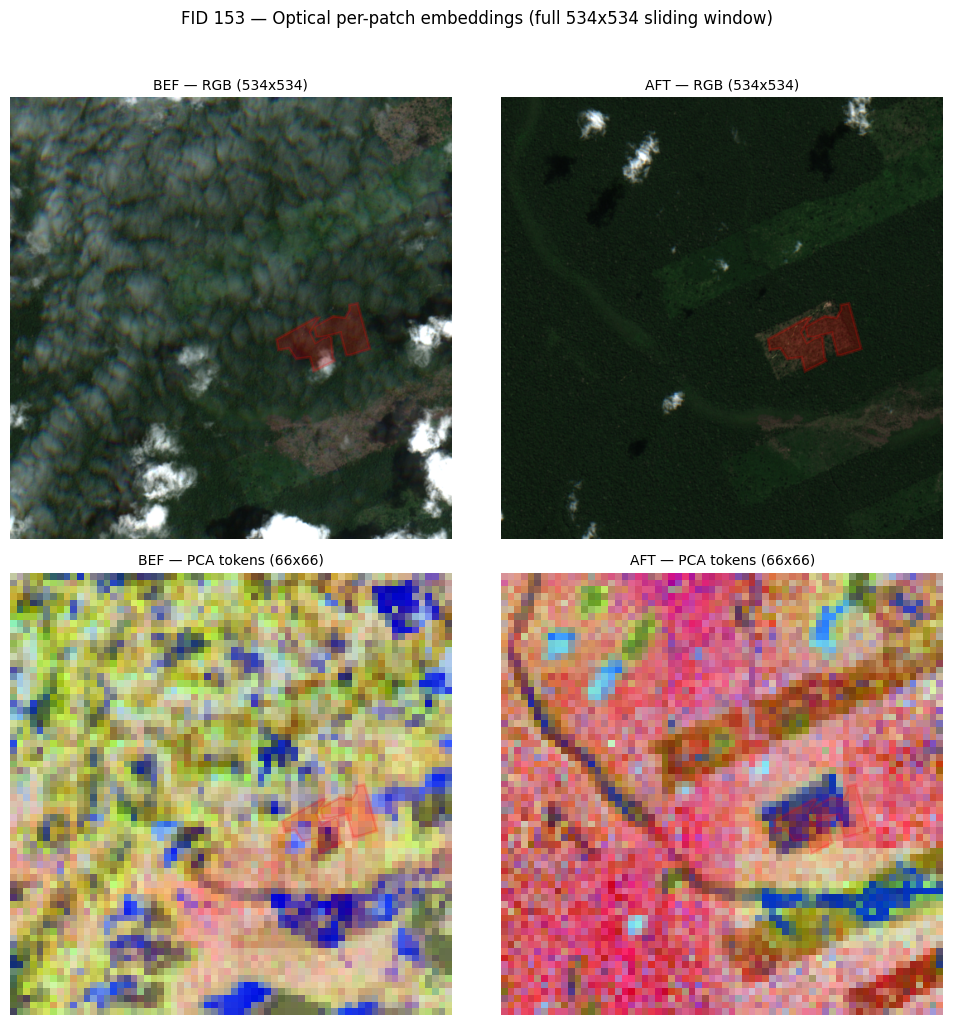

In [17]:
# PCA across all windows jointly (so colors are comparable)
windows_with_data = [w for w in ["evt", "bef", "aft"] if w in optical_results]

# Stack all tokens for joint PCA fitting
all_tokens = np.concatenate(
    [optical_results[w]['tokens'].reshape(-1, EMBED_DIM) for w in windows_with_data]
)
pca = PCA(n_components=3)
pca.fit(all_tokens)
print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Token grid shape: {optical_results[windows_with_data[0]]['tokens'].shape}")

# Plot: row 1 = RGB image (full 534x534), row 2 = PCA embedding map (token grid)
fig, axes = plt.subplots(2, len(windows_with_data), figsize=(5 * len(windows_with_data), 10))
if len(windows_with_data) == 1:
    axes = axes[:, np.newaxis]

for col, window in enumerate(windows_with_data):
    res = optical_results[window]
    data = res['data']
    tokens = res['tokens']
    transform = res['transform']
    crs = res['crs']
    th, tw = tokens.shape[:2]

    # Row 1: RGB image full 534x534 (B4=index 3, B3=index 2, B2=index 1)
    ax_rgb = axes[0, col]
    rgb = data[[3, 2, 1]].transpose(1, 2, 0)
    rgb = np.clip(rgb / 3000, 0, 1)
    ax_rgb.imshow(rgb)
    add_polygon_overlay(ax_rgb, FID, transform, crs, MASTER_TILE)
    ax_rgb.set_title(f"{window.upper()} — RGB (534x534)", fontsize=10)
    ax_rgb.axis("off")

    # Row 2: PCA of patch tokens (66x66 grid covering the full tile)
    ax_pca = axes[1, col]
    tokens_flat = tokens.reshape(-1, EMBED_DIM)
    pca_rgb = pca.transform(tokens_flat).reshape(th, tw, 3)
    for c in range(3):
        vmin, vmax = pca_rgb[:, :, c].min(), pca_rgb[:, :, c].max()
        pca_rgb[:, :, c] = (pca_rgb[:, :, c] - vmin) / (vmax - vmin + 1e-10)
    ax_pca.imshow(pca_rgb, interpolation="nearest")
    # Overlay polygon scaled to token grid (PATCH_SIZE pixels per token)
    add_polygon_overlay_on_grid(ax_pca, FID, transform, crs, PATCH_SIZE)
    ax_pca.set_title(f"{window.upper()} — PCA tokens ({th}x{tw})", fontsize=10)
    ax_pca.axis("off")

fig.suptitle(f"FID {FID} — Optical per-patch embeddings (full 534x534 sliding window)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Cosine similarity: event vs before/after

For each patch, compute cosine similarity between its event embedding and its before/after embedding.

- High similarity = no change  
- Low similarity = change detected

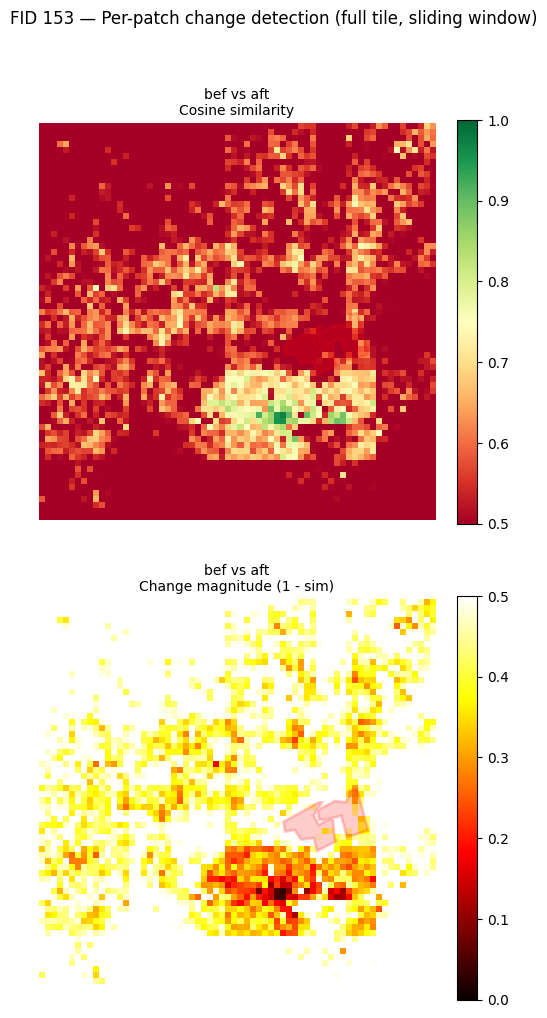

In [18]:
def cosine_similarity_map(tokens_a, tokens_b):
    """Per-patch cosine similarity between two token grids.
    Returns: (H, W) array of similarities in [-1, 1].
    """
    h, w = tokens_a.shape[:2]
    a = tokens_a.reshape(-1, EMBED_DIM)
    b = tokens_b.reshape(-1, EMBED_DIM)
    a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-10)
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-10)
    return (a_norm * b_norm).sum(axis=1).reshape(h, w)


comparisons = []
if "evt" in optical_results and "bef" in optical_results:
    comparisons.append(("evt vs bef", "evt", "bef"))
if "evt" in optical_results and "aft" in optical_results:
    comparisons.append(("evt vs aft", "evt", "aft"))
if "bef" in optical_results and "aft" in optical_results:
    comparisons.append(("bef vs aft", "bef", "aft"))

if comparisons:
    n_comp = len(comparisons)
    fig, axes = plt.subplots(2, n_comp, figsize=(5 * n_comp, 10))
    if n_comp == 1:
        axes = axes[:, np.newaxis]

    for col, (title, w1, w2) in enumerate(comparisons):
        sim = cosine_similarity_map(optical_results[w1]['tokens'], optical_results[w2]['tokens'])
        transform = optical_results[w1]['transform']
        crs = optical_results[w1]['crs']

        ax = axes[0, col]
        im = ax.imshow(sim, cmap="RdYlGn", vmin=0.5, vmax=1.0, interpolation="nearest")
        add_polygon_overlay_on_grid(ax, FID, transform, crs, PATCH_SIZE)
        ax.set_title(f"{title}\nCosine similarity", fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)

        ax2 = axes[1, col]
        change = 1 - sim
        im2 = ax2.imshow(change, cmap="hot", vmin=0, vmax=0.5, interpolation="nearest")
        add_polygon_overlay_on_grid(ax2, FID, transform, crs, PATCH_SIZE)
        ax2.set_title(f"{title}\nChange magnitude (1 - sim)", fontsize=10)
        ax2.axis("off")
        plt.colorbar(im2, ax=ax2, fraction=0.046)

    fig.suptitle(f"FID {FID} — Per-patch change detection (full tile, sliding window)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

## 6. SAR + Joint embeddings (multimodal)

In [19]:
# SAR-only embeddings (sliding window over full tile)
print("Loading SAR model...")
model_sar = load_croma_model(['sar'])

sar_results = {}
for window, path in s1_tiles.items():
    data, transform, crs = load_full_tile(path)
    tokens = extract_full_tile_tokens(model_sar, data, modality="sar")
    gap = tokens.reshape(-1, EMBED_DIM).mean(axis=0)
    sar_results[window] = {
        'data': data, 'tokens': tokens, 'gap': gap,
        'transform': transform, 'crs': crs,
    }
    print(f"  SAR {window}: tokens {tokens.shape}, norm={np.linalg.norm(gap):.2f}")

del model_sar
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Done.")
print("\nNote: Joint mode requires both modalities in the same crop.")
print("Skipping joint for now — can be added by combining encode_crop calls per window.")

Loading SAR model...
  SAR evt: tokens (66, 66, 768), norm=17.59
  SAR bef: tokens (66, 66, 768), norm=17.70
  SAR aft: tokens (66, 66, 768), norm=17.74
Done.

Note: Joint mode requires both modalities in the same crop.
Skipping joint for now — can be added by combining encode_crop calls per window.


## 7. Compare modalities: optical vs SAR vs joint change maps

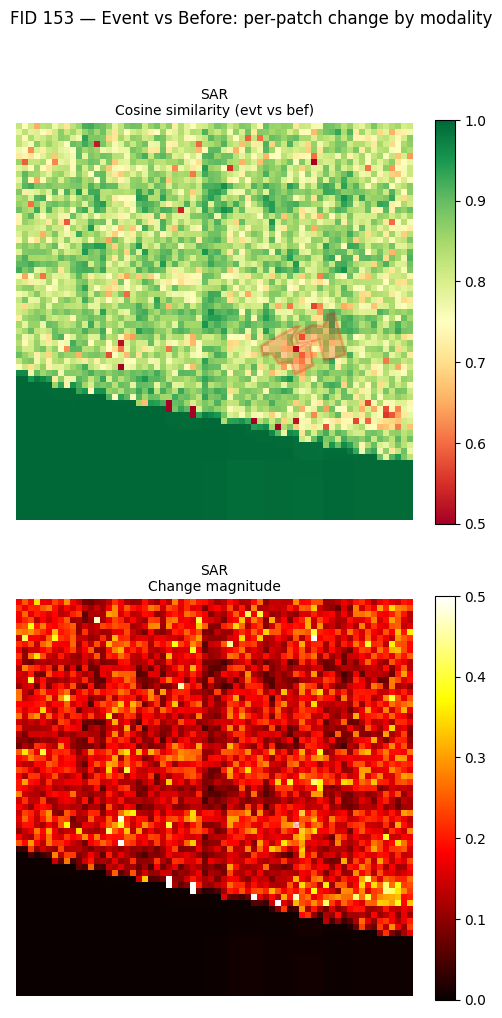

In [20]:
# Compare evt vs bef change maps across modalities
modalities = []
if "evt" in optical_results and "bef" in optical_results:
    modalities.append(("Optical", optical_results))
if "evt" in sar_results and "bef" in sar_results:
    modalities.append(("SAR", sar_results))

n_mod = len(modalities)
if n_mod > 0:
    fig, axes = plt.subplots(2, n_mod, figsize=(5 * n_mod, 10))
    if n_mod == 1:
        axes = axes[:, np.newaxis]

    for col, (name, results) in enumerate(modalities):
        sim = cosine_similarity_map(results["evt"]['tokens'], results["bef"]['tokens'])
        transform = results["evt"]['transform']
        crs = results["evt"]['crs']

        ax = axes[0, col]
        im = ax.imshow(sim, cmap="RdYlGn", vmin=0.5, vmax=1.0, interpolation="nearest")
        add_polygon_overlay_on_grid(ax, FID, transform, crs, PATCH_SIZE)
        ax.set_title(f"{name}\nCosine similarity (evt vs bef)", fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)

        ax2 = axes[1, col]
        change = 1 - sim
        im2 = ax2.imshow(change, cmap="hot", vmin=0, vmax=0.5, interpolation="nearest")
        add_polygon_overlay_on_grid(ax2, FID, transform, crs, PATCH_SIZE)
        ax2.set_title(f"{name}\nChange magnitude", fontsize=10)
        ax2.axis("off")
        plt.colorbar(im2, ax=ax2, fraction=0.046)

    fig.suptitle(f"FID {FID} — Event vs Before: per-patch change by modality", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Need both evt and bef windows for at least one modality")


## 8. Embedding statistics

In [21]:
# Summary statistics for all extracted embeddings
print(f"FID: {FID}")
print(f"{'Modality':<12} {'Window':<6} {'GAP norm':>10} {'Token norm (mean)':>18} {'Token norm (std)':>16}")
print("-" * 65)

for name, results in [("Optical", optical_results), ("SAR", sar_results)]:
    for window in ["evt", "bef", "aft"]:
        if window not in results:
            continue
        gap = results[window]['gap']
        tokens = results[window]['tokens'].reshape(-1, EMBED_DIM)
        norms = np.linalg.norm(tokens, axis=1)
        print(f"{name:<12} {window:<6} {np.linalg.norm(gap):>10.2f} {norms.mean():>18.2f} {norms.std():>16.2f}")

# Verify GAP ≈ mean of tokens
print("\nVerification: GAP should equal mean of patch tokens")
for name, results in [("Optical", optical_results), ("SAR", sar_results)]:
    for window in ["evt", "bef", "aft"]:
        if window not in results:
            continue
        gap = results[window]['gap']
        tokens_mean = results[window]['tokens'].reshape(-1, EMBED_DIM).mean(axis=0)
        diff = np.linalg.norm(gap - tokens_mean)
        print(f"  {name} {window}: ||GAP - mean(tokens)|| = {diff:.6f}")


FID: 153
Modality     Window   GAP norm  Token norm (mean) Token norm (std)
-----------------------------------------------------------------
Optical      bef         16.59              25.36             1.64
Optical      aft         17.48              25.11             1.80
SAR          evt         17.59              25.48             1.87
SAR          bef         17.70              25.48             1.85
SAR          aft         17.74              25.49             1.86

Verification: GAP should equal mean of patch tokens
  Optical bef: ||GAP - mean(tokens)|| = 0.000000
  Optical aft: ||GAP - mean(tokens)|| = 0.000000
  SAR evt: ||GAP - mean(tokens)|| = 0.000000
  SAR bef: ||GAP - mean(tokens)|| = 0.000000
  SAR aft: ||GAP - mean(tokens)|| = 0.000000
